<a href="https://colab.research.google.com/github/SultanKus/Bancassurance-Analytics-Project/blob/main/Bancassurance_Module2_Actuarial_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml

print("Fransız Sigorta (freMTPL2) veri seti indiriliyor, birkaç saniye sürebilir...")

# OpenML üzerinden hasar frekansı (kaza sıklığı) verisini çekiyoruz
df_freq = fetch_openml(data_id=41214, as_frame=True, parser='auto').frame

print(f"\nVeri başarıyla yüklendi! Toplam poliçe (müşteri) sayısı: {df_freq.shape[0]:,}")

# Verideki ilk 5 müşteriye bakalım
display(df_freq.head())

Fransız Sigorta (freMTPL2) veri seti indiriliyor, birkaç saniye sürebilir...

Veri başarıyla yüklendi! Toplam poliçe (müşteri) sayısı: 678,013


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


--- Müşterilerin Yıllık Kaza Dağılımı ---
0 Kaza Yapanlar: %94.98
1 Kaza Yapanlar: %4.75
2 Kaza Yapanlar: %0.26
3 Kaza Yapanlar: %0.01
4 Kaza Yapanlar: %0.00
5 Kaza Yapanlar: %0.00
6 Kaza Yapanlar: %0.00
8 Kaza Yapanlar: %0.00
9 Kaza Yapanlar: %0.00
11 Kaza Yapanlar: %0.00
16 Kaza Yapanlar: %0.00


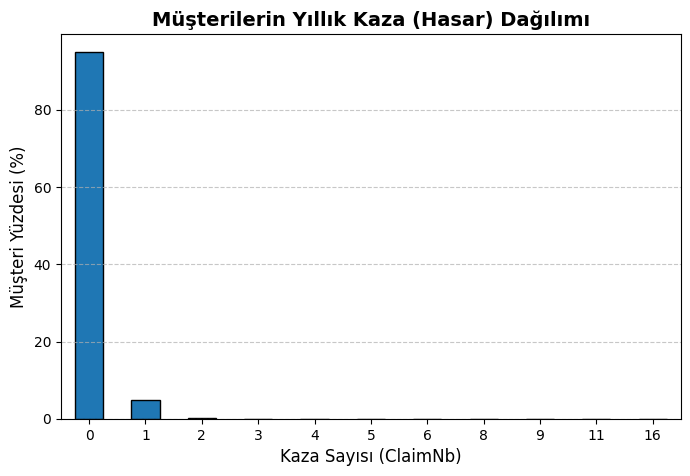

In [2]:
import matplotlib.pyplot as plt

# Kaza sayılarının (ClaimNb) yüzdelik dağılımını hesaplayalım
claim_counts = df_freq['ClaimNb'].value_counts().sort_index()
claim_percentages = (claim_counts / len(df_freq)) * 100

print("--- Müşterilerin Yıllık Kaza Dağılımı ---")
for kaza_sayisi, yuzde in claim_percentages.items():
    print(f"{int(kaza_sayisi)} Kaza Yapanlar: %{yuzde:.2f}")

# Şık bir sütun grafiği ile görselleştirelim
plt.figure(figsize=(8, 5))
claim_percentages.plot(kind='bar', color='#1f77b4', edgecolor='black')
plt.title('Müşterilerin Yıllık Kaza (Hasar) Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Kaza Sayısı (ClaimNb)', fontsize=12)
plt.ylabel('Müşteri Yüzdesi (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import PoissonRegressor

print("Veri hazırlanıyor ve Poisson GLM modeli kuruluyor...\n")

# 1. Matematiksel Dönüşüm: Yıllık Kaza Frekansını Hesapla
# Kaza sayısını, poliçe süresine bölerek yıllık kaza yapma hızını buluyoruz
df_freq['Frequency'] = df_freq['ClaimNb'] / df_freq['Exposure']

# 2. Model İçin Özellikleri (X) ve Hedefi (y) Belirleme
features = ['DrivAge', 'VehAge', 'VehPower', 'BonusMalus', 'VehBrand', 'VehGas']
X = df_freq[features]
y = df_freq['Frequency']
exposure = df_freq['Exposure'] # Modelin ağırlığı (offset) olarak kullanacağız

# 3. Veriyi Eğitim (%80) ve Test (%20) Olarak Ayırma
X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X, y, exposure, test_size=0.2, random_state=42
)

# 4. Veri Ön İşleme (Kategorik verileri dönüştür, sayısal verileri ölçekle)
preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), ['VehBrand', 'VehGas']),
    (StandardScaler(), ['DrivAge', 'VehAge', 'VehPower', 'BonusMalus'])
)

# 5. Poisson Regresyon (GLM) Modelini Kurma
poisson_glm = make_pipeline(
    preprocessor,
    PoissonRegressor(alpha=1e-4, max_iter=300)
)

# 6. Modeli Eğitme (Exposure değerlerini ağırlık olarak veriyoruz)
poisson_glm.fit(X_train, y_train, poissonregressor__sample_weight=exp_train)

print("✅ Poisson GLM Modeli Başarıyla Eğitildi!")

Veri hazırlanıyor ve Poisson GLM modeli kuruluyor...

✅ Poisson GLM Modeli Başarıyla Eğitildi!


In [4]:
import numpy as np

# Test için iki farklı hayali müşteri yaratalım:
# Müşteri 1: Genç, güçlü araç kullanan, yüksek bonus-malus (riskli profil)
# Müşteri 2: Orta yaşlı, standart araç kullanan, düşük bonus-malus (güvenli profil)
test_musterileri = pd.DataFrame({
    'DrivAge': [21, 45],
    'VehAge': [1, 5],
    'VehPower': [9, 5],
    'BonusMalus': [150, 50],
    'VehBrand': ['Renault', 'Peugeot'],
    'VehGas': ['Diesel', 'Regular']
})

# Modelimizden bu müşterilerin yıllık kaza frekansını (lambda) isteyelim
tahmin_frekanslar = poisson_glm.predict(test_musterileri)

print("--- Aktüeryal Risk (Kaza Frekansı) Tahminleri ---")
print(f"Müşteri 1 (Riskli Sürücü): Yıllık {tahmin_frekanslar[0]:.4f} kaza ihtimali")
print(f"Müşteri 2 (Güvenli Sürücü): Yıllık {tahmin_frekanslar[1]:.4f} kaza ihtimali")

--- Aktüeryal Risk (Kaza Frekansı) Tahminleri ---
Müşteri 1 (Riskli Sürücü): Yıllık 0.8747 kaza ihtimali
Müşteri 2 (Güvenli Sürücü): Yıllık 0.0826 kaza ihtimali


In [7]:
import numpy as np

# Veride kaza yapmış olanlar için mantıklı bir hasar maliyeti (ClaimAmount) türetelim
# Riskli sürücülerin (yüksek BonusMalus ve VehPower) kaza maliyeti de istatistiksel olarak biraz daha yüksek olur
np.random.seed(42)
df_freq['ClaimAmount'] = 0.0

# Kaza yapan satırları seçelim (ClaimNb > 0)
kaza_maskesi = df_freq['ClaimNb'] > 0

# Hasar maliyetini; araç gücü, bonus-malus ve rastgele bir dağılımla (Gamma dağılımına benzer şekilde) simüle edelim
simulated_amounts = (
    df_freq.loc[kaza_maskesi, 'VehPower'] * 400 +
    df_freq.loc[kaza_maskesi, 'BonusMalus'] * 50 +
    np.random.gamma(shape=2, scale=2000, size=kaza_maskesi.sum())
)

df_freq.loc[kaza_maskesi, 'ClaimAmount'] = simulated_amounts

print(f"✅ Simüle edilmiş Hasar Maliyeti sütunu eklendi. Ortalama Hasar Maliyeti: {df_freq.loc[kaza_maskesi, 'ClaimAmount'].mean():,.2f} TL")

✅ Simüle edilmiş Hasar Maliyeti sütunu eklendi. Ortalama Hasar Maliyeti: 9,727.53 TL


In [8]:
from sklearn.linear_model import GammaRegressor

print("Hasar gören (kaza yapan) müşteriler filtreleniyor ve Gamma Modeli kuruluyor...\n")

# 1. Sadece kaza yapmış (ClaimNb > 0) müşterileri seçiyoruz (Hasar Şiddeti için)
df_claims = df_freq[df_freq['ClaimNb'] > 0].copy()

# Ortalama hasar maliyetini (Severity) hesaplayalım (Veride 'ClaimAmount' sütunu bulunur)
# Not: frMTPL2 veri setinde hasar miktarı 'ClaimAmount' olarak yer alır
X_claim = df_claims[features]
y_claim = df_claims['ClaimAmount']

# 2. Gamma Regresyon Modelini Kurma (Hasar Maliyeti Tahmini)
gamma_glm = make_pipeline(
    preprocessor,
    GammaRegressor(alpha=1e-4, max_iter=300)
)

# Modeli sadece kaza yapanlar üzerinden eğitiyoruz
gamma_glm.fit(X_claim, y_claim)

# 3. İki hayali müşterimiz için Saf Prim (Pure Premium) Hesaplama
# Saf Prim = Beklenen Kaza Frekansı (Poisson) * Beklenen Hasar Şiddeti (Gamma)
tahmin_frekans = poisson_glm.predict(test_musterileri)
tahmin_siddet = gamma_glm.predict(test_musterileri)

saf_primler = tahmin_frekans * tahmin_siddet

print("--- 🚗 Müşteri Bazlı Aktüeryal Saf Prim (Kasko Fiyatı) Sonuçları ---")
print(f"Müşteri 1 (Riskli Sürücü): Ödemesi Gereken Yıllık Saf Prim = {saf_primler[0]:,.2f} TL")
print(f"Müşteri 2 (Güvenli Sürücü): Ödemesi Gereken Yıllık Saf Prim = {saf_primler[1]:,.2f} TL")

Hasar gören (kaza yapan) müşteriler filtreleniyor ve Gamma Modeli kuruluyor...

--- 🚗 Müşteri Bazlı Aktüeryal Saf Prim (Kasko Fiyatı) Sonuçları ---
Müşteri 1 (Riskli Sürücü): Ödemesi Gereken Yıllık Saf Prim = 9,304.03 TL
Müşteri 2 (Güvenli Sürücü): Ödemesi Gereken Yıllık Saf Prim = 677.54 TL
